# KV Cache & 추론 최적화 - 실습 코드 2: KV Cache 직접 구현 및 메모리 분석

- Tutorial ID: `expand-kv-cache`
- Tutorial: KV Cache & 추론 최적화
- Section ID: `expand-kv-cache-code-2`
- Section: 실습 코드 2: KV Cache 직접 구현 및 메모리 분석

---

이 노트북은 **KV Cache(Key-Value Cache)** 를 처음부터 직접 구현해보면서 아래 세 가지를 코드와 숫자로 직접 확인하는 실습입니다.

1. Transformer의 self-attention에서 Q, K, V가 어떻게 계산되는지
2. 문장을 한 토큰씩 생성하는 과정(autoregressive generation)에서 왜 같은 계산을 반복하게 되는지, 그리고 그 반복을 KV Cache로 어떻게 없앨 수 있는지
3. 그 대가로 얼마나 많은 메모리를 추가로 쓰게 되는지

> 이 버전은 원본 실습 코드에 있던 들여쓰기 오류와, 실제로는 동작하지 않던 부분(모델이 튜플 `(logits, kv_cache)`를 반환하는데 텐서처럼 바로 슬라이싱하던 부분 등)을 바로잡아 **끝까지 실행 가능한 예제**로 다듬었습니다. 또한 처음 배우는 분들을 위해, 각 단계마다 "왜 이렇게 하는지"를 먼저 설명한 뒤 코드를 보여주는 순서로 재구성했습니다.


## 이 노트북에서 배우는 것

**학습 목표**
1. Q, K, V가 어떤 shape(형태)으로 만들어지고, 그것이 attention score로 이어지는 과정을 한 줄씩 추적한다.
2. autoregressive(자기회귀) decoding에서 "이전 K, V를 재사용"하면 계산을 얼마나 줄일 수 있는지 직접 확인한다.
3. 실제 LLM 스케일에서 KV Cache가 차지하는 메모리가 어느 정도인지 감을 잡는다.

**읽는 순서**
1. 먼저 하이퍼파라미터(`batch`, `seq_len`, `d_model` 등)의 의미를 확인합니다.
2. causal mask처럼 낯설 수 있는 개념은 아주 작은 예시로 먼저 눈으로 확인합니다.
3. `KVCacheAttention` 클래스를 한 줄씩 읽으며 shape 변화를 따라갑니다.
4. "cache를 쓰든 안 쓰든 결과가 정확히 같다"는 것을 코드로 직접 검증합니다.
5. 마지막으로 메모리 계산식을 손으로 따라가 보고, 그래프로 다시 확인합니다.

**주의**
- 숫자 하나하나를 외우기보다 "shape가 어떻게 바뀌는지"와 "정보가 어느 방향으로 흐르는지"에 집중하세요.
- 이 노트북은 PyTorch(`torch`)를 사용합니다. `torch`가 설치되어 있지 않은 환경(이 문서를 만든 환경 포함)에서는 코드만 있고 실행 결과가 비어 있을 수 있습니다. 이런 셀은 **Colab**이나 로컬 Jupyter, 또는 GPU 서버에서 직접 실행해서 결과를 확인하는 것을 권장합니다. (로직 자체는 NumPy로 동일하게 재구현해 결과가 정확히 일치함을 미리 검증했습니다.) 반대로 PyTorch가 필요 없는 메모리 계산·그래프 셀에는 이미 실행된 결과가 담겨 있습니다.


## KV Cache는 왜 필요할까?

GPT류의 언어모델은 문장을 한 번에 만들지 않고, **토큰을 하나씩 순서대로** 만듭니다. 그런데 순진하게 구현하면, 새 토큰을 만들 때마다 "지금까지 만들어진 문장 전체"를 매번 모델에 다시 넣게 됩니다.

```
1번째 생성: [나는]                       -> 다음 토큰 예측
2번째 생성: [나는, 오늘]                  -> 다음 토큰 예측 ("나는"도 다시 계산!)
3번째 생성: [나는, 오늘, 학교에]           -> 다음 토큰 예측 ("나는", "오늘"도 다시 계산!)
...
```

문제는, self-attention 계산에서 "나는"이라는 토큰의 Key와 Value는 **몇 번째 스텝에서 계산하든 항상 똑같다**는 점입니다. "나는"의 Key, Value는 자기 자신과 그 이전 토큰에게만 영향을 받고(causal mask 때문에 미래 토큰의 영향은 받지 않으므로), 뒤에 어떤 토큰이 추가되어도 절대 바뀌지 않습니다. 그런데도 매 스텝마다 이미 계산해 둔 값을 처음부터 다시 계산하는 것은 순수한 낭비입니다.

> 비유: 책을 읽으며 요약 노트를 쓴다고 생각해봅시다. 100페이지까지 읽고 101페이지로 넘어갈 때, 굳이 1페이지부터 다시 읽고 요약하지는 않습니다. 이미 써둔 요약 노트(Key, Value)는 그대로 두고, **새로 읽은 101페이지 분량만** 요약해서 노트에 추가하면 됩니다.

**KV Cache**는 바로 이 "요약 노트"입니다. 각 토큰의 Key, Value를 한 번 계산한 뒤 메모리에 저장(cache)해두고, 새 토큰이 들어올 때는 그 토큰의 Key, Value만 새로 계산해서 이어 붙입니다.

| | 저장(cache)해야 할까? | 이유 |
|---|---|---|
| Query | ❌ | 이번 스텝에서 한 번만 쓰고 버려짐 |
| Key   | ✅ | 이후 모든 스텝에서 "이 토큰을 봐도 될지" 비교할 때 반복해서 필요 |
| Value | ✅ | 이후 모든 스텝에서 "이 토큰의 정보를 얼마나 반영할지" 가중합할 때 반복해서 필요 |


## Q, K, V란 정확히 무엇일까? — 도서관 비유

Self-attention을 처음 보면 Q(Query), K(Key), V(Value)라는 이름부터 낯설게 느껴집니다. **도서관에서 책을 찾는 상황**에 비유하면 이해하기 쉽습니다.

- **Query(질의)**: 지금 내가 알고 싶은 것. "이 주제와 관련된 책이 있을까?" 하고 사서에게 묻는 질문.
- **Key(색인/태그)**: 도서관의 각 책에 붙어 있는 "이 책은 이런 주제를 다룹니다"라는 색인표. 내 Query와 얼마나 잘 맞는지 비교하는 데 쓰입니다.
- **Value(내용물)**: 실제 책의 내용. Query와 Key를 비교해서 "이 책이 얼마나 관련 있는지" 점수를 매긴 다음, 관련 있는 정도(가중치)만큼 그 책의 **내용(Value)** 을 가져와 섞습니다.

즉 attention은 다음 순서로 동작합니다.

1. 지금 토큰의 **Query**를, 지금까지 나온 모든 토큰의 **Key**와 하나씩 비교(내적)해서 "얼마나 관련 있는지" 점수(score)를 매깁니다.
2. 이 점수를 **softmax**로 "합이 1인 확률"로 바꿉니다. (관련 있는 토큰일수록 확률이 커짐)
3. 이 확률을 가중치로 삼아, 각 토큰의 **Value**를 가중합(weighted sum)해서 최종 출력을 만듭니다.

코드로 보면 각 단계는 이렇게 대응됩니다.

| 개념 | 코드 | 의미 |
|---|---|---|
| Query 만들기 | `Q = self.q_proj(x)` | 지금 토큰이 "무엇을 찾는지" 벡터로 표현 |
| Key 만들기 | `K = self.k_proj(x)` | 각 토큰의 "색인표"를 벡터로 표현 |
| Value 만들기 | `V = self.v_proj(x)` | 각 토큰의 "실제 내용"을 벡터로 표현 |
| 관련도 점수 | `Q @ K.transpose(-2, -1)` | Query와 Key를 내적해서 "얼마나 관련 있는지" 계산 |
| 확률로 변환 | `torch.softmax(scores, dim=-1)` | 점수를 합이 1인 확률로 변환 |
| 정보 가져오기 | `attn @ V` | 확률(가중치)만큼 Value를 섞어서 최종 정보를 만듦 |

또 하나, 실제 구현에서는 이 과정을 **여러 개의 head로 나누어 병렬로** 수행합니다(Multi-Head Attention). 하나의 큰 attention을 계산하는 대신 차원을 n개로 쪼개서 n번 독립적으로 attention을 계산한 뒤 다시 합치는 방식인데, 이렇게 하면 "문법 구조에 집중하는 head", "의미적 유사성에 집중하는 head"처럼 head마다 서로 다른 관점에서 관계를 학습할 수 있다는 장점이 있습니다. 아래 코드의 `n_heads`, `d_k`(head 하나의 차원)가 바로 이 부분에 해당합니다.


In [ ]:
import torch
import torch.nn as nn
import math

# ── 이번 실습에서 사용할 하이퍼파라미터 이름 정리 ──
# d_model : 토큰 하나를 표현하는 벡터의 차원 수(임베딩 차원). 흔히 512, 768, 4096 등을 씁니다.
# n_heads : attention을 몇 개의 head로 나눌지 결정하는 값.
# d_k     : head 하나가 담당하는 차원 수 (= d_model // n_heads)
# batch   : 한 번에 처리하는 문장(시퀀스)의 개수
# seq_len : 문장(시퀀스)의 토큰 개수
#
# 예) d_model=512, n_heads=8 이면 -> 8개의 head가 각각 512/8 = 64차원씩 나누어 담당합니다.
d_model_example = 512
n_heads_example = 8
print(f"d_model={d_model_example}, n_heads={n_heads_example} 이면 "
      f"head 하나의 차원 d_k = {d_model_example // n_heads_example}")


### 미리보기: causal mask는 어떤 모양일까?

뒤에서 만들 `KVCacheAttention` 코드 안에는 `torch.triu(...)`로 만드는 causal mask가 등장합니다. 코드부터 보면 "삼각행렬이 왜 나오지?" 싶을 수 있으니, 라이브러리 없이 순수 파이썬으로 먼저 그 모양을 확인해봅니다.

**규칙은 단순합니다: 토큰은 자기 자신과 그 이전 토큰만 볼 수 있고, 미래 토큰은 볼 수 없습니다.**


In [1]:
# 먼저 아주 작은 예시로 causal mask가 어떤 모양인지 순수 파이썬으로 직접 확인해봅니다.
# (라이브러리 없이도 만들 수 있다는 걸 보여주기 위해 일부러 torch 없이 작성했습니다.)
seq_len_demo = 5

# 규칙: "j번째 토큰이 i번째 토큰보다 미래(j > i)"이면 볼 수 없음(True = 마스킹 대상)
causal_mask_demo = [[j > i for j in range(seq_len_demo)] for i in range(seq_len_demo)]

print(f"토큰이 {seq_len_demo}개 있다고 가정 (True = 미래라서 못 봄 / False = 과거(또는 자신)라서 볼 수 있음)\n")
header = "        " + "".join(f"tok{j:<3}" for j in range(seq_len_demo))
print(header)
for i, row in enumerate(causal_mask_demo):
    marks = "".join(f"{'T':<6}" if v else f"{'F':<6}" for v in row)
    print(f"tok{i} 시야: {marks}")

print("\n예) tok0(첫 토큰)은 자기 자신(tok0)만 볼 수 있고, tok1~tok4는 아직 만들어지지 않은 미래라 볼 수 없습니다.")
print("    tok4(마지막 토큰)는 tok0~tok4 전부를 볼 수 있습니다 (자신 포함, 전부 과거이거나 자신이므로).")


토큰이 5개 있다고 가정 (True = 미래라서 못 봄 / False = 과거(또는 자신)라서 볼 수 있음)

        tok0  tok1  tok2  tok3  tok4  
tok0 시야: F     T     T     T     T     
tok1 시야: F     F     T     T     T     
tok2 시야: F     F     F     T     T     
tok3 시야: F     F     F     F     T     
tok4 시야: F     F     F     F     F     

예) tok0(첫 토큰)은 자기 자신(tok0)만 볼 수 있고, tok1~tok4는 아직 만들어지지 않은 미래라 볼 수 없습니다.
    tok4(마지막 토큰)는 tok0~tok4 전부를 볼 수 있습니다 (자신 포함, 전부 과거이거나 자신이므로).


## KVCacheAttention 구현하기

이제 위에서 살펴본 개념들(Q/K/V, multi-head, causal mask, KV Cache)을 모두 합쳐 하나의 `KVCacheAttention` 클래스로 구현합니다. 아래 코드에는 각 단계마다 "지금 shape가 어떻게 되는지", "왜 이 연산이 필요한지"를 주석으로 달아두었습니다.

핵심은 `forward` 메서드의 두 갈래입니다.

- **`kv_cache=None`** (Prefill 단계): 프롬프트 전체를 한 번에 넣고, 그 결과로 K, V 캐시를 새로 만듭니다.
- **`kv_cache=(past_K, past_V)`** (Decode 단계): 새 토큰 1개만 넣고, 새로 계산한 K, V를 과거 캐시 뒤에 이어 붙입니다.

cache를 쓰든 안 쓰든 결과가 정확히 같아야 한다는 것은, 바로 다음 섹션에서 직접 코드로 검증합니다.


In [ ]:
class KVCacheAttention(nn.Module):
    """KV Cache를 적용한 Multi-Head Self-Attention.

    - Without KV Cache: 매 스텝마다 지금까지의 모든 토큰에 대해 K, V를 처음부터 다시 계산
    - With KV Cache   : 이전 스텝에서 계산해 둔 K, V는 그대로 재사용하고,
                        새로 들어온 토큰의 K, V만 추가로 계산
    """

    def __init__(self, d_model=512, n_heads=8):
        super().__init__()
        assert d_model % n_heads == 0, "d_model은 n_heads로 나누어 떨어져야 합니다."
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # head 하나가 담당하는 차원 수
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.scale = math.sqrt(self.d_k)  # scaled dot-product attention의 스케일 값

    def forward(self, x, kv_cache=None, use_cache=True, verbose=False):
        """
        x: (batch, seq_len_new, d_model)
            - kv_cache가 None이면: 이번에 새로 넣는 "전체" 시퀀스
              (prefill 단계 — 보통 프롬프트 전체가 여기 해당)
            - kv_cache가 있으면  : 이번에 "새로" 추가된 토큰만!
              (decode 단계 — 보통 seq_len_new=1)
        kv_cache: (past_K, past_V) 튜플 또는 None
            - past_K, past_V shape: (batch, n_heads, past_len, d_k)
        use_cache: True면 이번 스텝의 K, V를 다음 스텝에서 쓸 수 있도록 반환합니다.
        verbose: True면 중간 텐서들의 shape을 출력합니다 (학습용 디버깅 옵션).
        """
        batch = x.size(0)

        # 1) 입력 x를 세 개의 서로 다른 선형 변환(Linear)에 통과시켜 Q, K, V를 만듭니다.
        #    .view(...)로 (batch, seq_len_new, n_heads, d_k)로 head를 나누고,
        #    .transpose(1, 2)로 (batch, n_heads, seq_len_new, d_k)로 순서를 바꿉니다.
        #    (head 차원을 앞으로 당겨야 head별로 독립적인 행렬곱을 배치 연산으로 처리할 수 있습니다.)
        Q = self.q_proj(x).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.k_proj(x).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.v_proj(x).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)

        if verbose:
            print(f"[1] 새로 계산한 Q, K, V shape : {tuple(Q.shape)}  (batch, n_heads, seq_len_new, d_k)")

        # 2) KV Cache 결합: 새로 계산한 K, V를 "과거에 저장해둔" K, V 뒤에 이어 붙입니다.
        #    시퀀스 길이 축(dim=2)으로 concat하므로, 길이가 past_len + seq_len_new로 늘어납니다.
        #    ※ 이 부분이 KV Cache의 핵심입니다: Q는 "새 토큰"만 계산하면 되지만,
        #      attention이 과거를 참조하려면 K, V는 "과거 전체 + 새 토큰"을 갖고 있어야 합니다.
        if kv_cache is not None:
            past_K, past_V = kv_cache
            K = torch.cat([past_K, K], dim=2)  # (batch, n_heads, past_len + seq_len_new, d_k)
            V = torch.cat([past_V, V], dim=2)
            if verbose:
                print(f"[2] 캐시와 결합한 뒤 K, V shape : {tuple(K.shape)}  "
                      f"(과거 {past_K.size(2)}개 + 신규 {Q.size(2)}개)")

        # 3) 다음 스텝에서 재사용할 수 있도록, 이번 스텝 결과의 K, V를 저장해 둡니다.
        new_kv_cache = (K, V) if use_cache else None

        # 4) attention score 계산: Q와 K를 내적해서 "새 토큰이 각 위치와 얼마나 관련 있는지"를 구합니다.
        #    Q            : (batch, n_heads, seq_len_q, d_k)
        #    K.transpose  : (batch, n_heads, d_k, seq_len_k)
        #    Q @ K^T      : (batch, n_heads, seq_len_q, seq_len_k)
        #    sqrt(d_k)로 나누는 이유: d_k가 커질수록 내적 값의 분산도 커져서 softmax가
        #    한쪽으로 쏠리기 쉬워지는데(값이 큰 쪽 확률만 1에 가까워짐), 이를 완화하기 위한
        #    스케일링입니다 (Scaled Dot-Product Attention).
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        seq_len_q = Q.size(2)
        seq_len_k = K.size(2)

        if verbose:
            print(f"[3] attention score shape     : {tuple(scores.shape)}  "
                  f"(batch, n_heads, seq_len_q, seq_len_k)")

        # 5) Causal mask: "미래 토큰은 보면 안 된다"는 규칙을 적용합니다.
        #    - Prefill(seq_len_q > 1)일 때는 반드시 필요합니다. 한 번에 여러 토큰을 계산하므로,
        #      i번째 위치가 자신보다 뒤(j > i)에 있는 토큰을 보지 못하게 막아야 합니다.
        #      (바로 위 "causal mask 미리보기" 셀에서 확인한 True/False 표와 동일한 로직입니다.)
        #    - Decode(kv_cache 존재, 보통 seq_len_q == 1)일 때는 새 토큰 1개가
        #      "이미 만들어져 있는 과거 토큰들 전체"를 보는 것이라 애초에 '미래' 토큰이
        #      존재하지 않으므로 마스크를 새로 만들 필요가 없습니다.
        #      (그래서 매 스텝 다시 마스크를 만드는 비용도 아낄 수 있습니다.)
        if seq_len_q > 1 or kv_cache is None:
            causal_mask = torch.triu(
                torch.ones(seq_len_q, seq_len_k, device=x.device),
                diagonal=seq_len_k - seq_len_q + 1
            ).bool()
            # mask가 True인 위치의 score를 아주 작은 값(-1e9)으로 채우면,
            # softmax를 통과한 뒤 그 위치의 확률은 사실상 0이 됩니다.
            scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), -1e9)
            if verbose:
                print(f"[4] causal mask 적용됨 (True={int(causal_mask.sum())}개 위치를 -1e9로 채움)")

        # 6) softmax로 score를 "합이 1인 확률"로 바꾸고, 그 확률로 V를 가중합합니다.
        attn = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, V)  # (batch, n_heads, seq_len_q, d_k)

        # 7) 나뉘어 있던 head를 다시 하나로 합쳐 (batch, seq_len_q, d_model) 형태로 되돌립니다.
        output = output.transpose(1, 2).contiguous().view(batch, -1, self.n_heads * self.d_k)

        if verbose:
            print(f"[5] head를 합친 뒤 output shape : {tuple(output.shape)}  (batch, seq_len_q, d_model)")

        return self.out_proj(output), new_kv_cache


## 검증: cache를 쓰든 안 쓰든 결과가 똑같아야 한다

KV Cache는 "근사"가 아니라 "정확히 같은 계산을 더 빠르게 하는 방법"이어야 합니다. 즉, ① 토큰을 한 번에 전부 넣어 계산한 결과와 ② 토큰을 하나씩 넣으면서 cache를 쌓아 올린 결과가 **완전히 동일**해야 합니다. 이걸 코드로 직접 확인해봅시다. (`verbose=True`로 중간 shape도 함께 출력해서, 위에서 설명한 shape 변화를 실제 값으로 확인합니다.)


In [ ]:
torch.manual_seed(0)

d_model, n_heads, seq_len, batch = 16, 4, 5, 1
layer = KVCacheAttention(d_model=d_model, n_heads=n_heads)
layer.eval()  # 이 예제엔 dropout이 없어 큰 차이는 없지만, 습관적으로 평가 모드로 전환합니다.

x_full = torch.randn(batch, seq_len, d_model)  # 5개 토큰짜리 가상의 임베딩 시퀀스

# ① cache 없이, 5개 토큰을 한 번에 계산 (prefill과 동일한 방식)
with torch.no_grad():
    out_all_at_once, _ = layer(x_full, kv_cache=None, use_cache=False)

# ② cache를 사용해, 토큰을 한 개씩 순서대로 넣으며 계산
#    (처음 2개 토큰만 verbose=True로 shape 변화를 함께 출력합니다)
outputs_step_by_step = []
kv_cache = None
with torch.no_grad():
    for t in range(seq_len):
        x_t = x_full[:, t:t + 1, :]  # 토큰 1개만 슬라이싱 -> shape: (batch, 1, d_model)
        if t < 2:
            print(f"--- {t}번째 토큰 처리 ---")
        out_t, kv_cache = layer(x_t, kv_cache=kv_cache, use_cache=True, verbose=(t < 2))
        outputs_step_by_step.append(out_t)

out_step_by_step = torch.cat(outputs_step_by_step, dim=1)

# ③ 두 결과 비교
max_diff = (out_all_at_once - out_step_by_step).abs().max().item()
print(f"\n두 결과의 shape : {tuple(out_all_at_once.shape)} vs {tuple(out_step_by_step.shape)}")
print(f"최대 절대 오차   : {max_diff:.2e}  (부동소수점 연산 오차 수준이면 사실상 0)")

assert torch.allclose(out_all_at_once, out_step_by_step, atol=1e-5), \
    "cache 사용 여부에 따라 결과가 달라지면 안 됩니다!"
print("\n✅ cache를 쓰든 안 쓰든 attention 결과가 동일합니다.")
print("   => KV Cache는 '다른 계산'이 아니라 '같은 계산을 재사용하는 것'임을 확인했습니다.")


## 진짜 "생성"을 해보려면? — 아주 작은 장난감 언어모델 만들기

`KVCacheAttention`은 attention 레이어 하나일 뿐입니다. 실제로 "다음 토큰을 생성"하려면 아래 두 가지가 더 필요합니다.

1. 정수 토큰 ID를 벡터로 바꿔주는 **임베딩(embedding)** 레이어
2. attention을 통과한 벡터를 다시 "각 단어일 확률(점수)"로 바꿔주는 **출력 head(lm_head)**

또한 실제 LLM은 이런 attention 블록을 수십 개 층으로 쌓습니다. 그래서 KV Cache도 레이어 하나가 아니라 **레이어마다 하나씩**, 총 `n_layers`개의 캐시를 리스트로 관리해야 합니다.

아래 `TinyLanguageModel`은 이 최소 구성만 가진 장난감 모델입니다. (실제 GPT류 모델에는 residual 연결, LayerNorm, feed-forward 레이어도 들어가지만, 여기서는 **KV Cache 동작 자체**에 집중하기 위해 생략했습니다.) 가중치는 무작위로 초기화되어 있고 학습되지 않았으므로, 생성되는 토큰이 실제 문장처럼 의미가 통하지는 않습니다 — 이 실습에서 확인하려는 것은 "말이 되는 문장을 만드는가"가 아니라 "cache를 쓰든 안 쓰든 정확히 같은 토큰을 생성하는가, 그리고 얼마나 빨라지는가"입니다.


In [ ]:
class TinyLanguageModel(nn.Module):
    """KV Cache 동작을 눈으로 확인하기 위한 아주 작은 장난감 언어모델.

    구조: 토큰 임베딩 -> KVCacheAttention x n_layers -> 출력 head(lm_head)
    (residual 연결, LayerNorm, feed-forward 레이어는 KV Cache 설명에 필수가 아니므로
     생략했습니다. 실제 GPT류 모델에는 이런 구성요소가 추가로 들어갑니다.)
    """

    def __init__(self, vocab_size=50, d_model=32, n_heads=4, n_layers=2):
        super().__init__()
        self.n_layers = n_layers
        # 정수 토큰 ID(0 ~ vocab_size-1)를 d_model 차원의 벡터로 바꿔주는 lookup table
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # attention block을 n_layers개 쌓습니다. (실제 GPT류 모델과 동일한 아이디어)
        self.layers = nn.ModuleList([
            KVCacheAttention(d_model=d_model, n_heads=n_heads) for _ in range(n_layers)
        ])
        # d_model 차원의 벡터를 다시 vocab_size 차원으로 되돌려 "다음 토큰 점수(logit)"를 계산합니다.
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, kv_cache=None, use_cache=True):
        """
        token_ids: (batch, seq_len_new) 정수 텐서 (토큰 ID)
        kv_cache : 레이어별 캐시 리스트 [(K_0, V_0), (K_1, V_1), ...] 또는 None
                   (레이어마다 독립적인 K, V를 캐싱하므로 레이어 개수만큼 리스트로 관리합니다.)
        """
        x = self.token_embedding(token_ids)  # (batch, seq_len_new, d_model)

        new_kv_cache = []
        for i, layer in enumerate(self.layers):
            # kv_cache가 있으면 "이 레이어 몫"만 꺼내서 넘겨주고, 없으면 None(=처음 계산)을 넘깁니다.
            layer_past = kv_cache[i] if kv_cache is not None else None
            x, layer_new_cache = layer(x, kv_cache=layer_past, use_cache=use_cache)
            new_kv_cache.append(layer_new_cache)

        logits = self.lm_head(x)  # (batch, seq_len_new, vocab_size)
        return logits, (new_kv_cache if use_cache else None)


## 생성 함수 두 가지: cache 없이 vs cache 사용

이제 실제로 토큰을 이어서 생성하는 두 가지 함수를 만듭니다. 다음 토큰은 확률이 가장 높은 것을 그대로 고르는 **greedy decoding**(`argmax`)으로 단순화했습니다. (실전에서는 temperature, top-k, top-p 같은 샘플링 기법도 쓰이지만, 이 실습의 초점은 "cache가 결과와 속도에 미치는 영향"이므로 가장 단순한 방식을 사용합니다.)


In [ ]:
def generate_without_cache(model, input_ids, max_new_tokens=20):
    """KV Cache 없이 생성: 매 스텝마다 지금까지의 전체 시퀀스를 처음부터 다시 계산합니다.

    1스텝: [t0]                -> 길이 1 전체 계산
    2스텝: [t0, t1]             -> 길이 2 전체 다시 계산 (t0도 또 계산함!)
    3스텝: [t0, t1, t2]         -> 길이 3 전체 다시 계산 (t0, t1도 또 계산함!)
    ...
    총 계산량은 1 + 2 + ... + N에 비례해서, 생성 길이가 길어질수록 훨씬 더 빠르게 늘어납니다.
    """
    tokens = input_ids.clone()
    total_flops = 0  # "지금까지 처리한 토큰 위치 수"를 연산량의 대략적인 척도로 사용합니다.

    for _ in range(max_new_tokens):
        # model이 (logits, kv_cache) 튜플을 반환하므로 반드시 두 개로 나눠 받아야 합니다.
        logits, _ = model(tokens, kv_cache=None, use_cache=False)  # 매번 전체 시퀀스를 새로 계산
        next_token = logits[:, -1:, :].argmax(dim=-1)  # 마지막 위치의 다음 토큰을 예측 (greedy)
        tokens = torch.cat([tokens, next_token], dim=1)
        total_flops += tokens.size(1)

    return tokens, total_flops


def generate_with_cache(model, input_ids, max_new_tokens=20):
    """KV Cache로 생성: 이미 계산해 둔 과거 K, V는 그대로 두고, 새 토큰의 K, V만 계산합니다.

    0스텝 (prefill): [t0]        -> 프롬프트 전체를 한 번에 처리하며 캐시를 만듭니다.
    1스텝 (decode) : [t1]        -> 새 토큰 1개만 처리 + 저장된 캐시 재사용
    2스텝 (decode) : [t2]        -> 새 토큰 1개만 처리 + 저장된 캐시 재사용
    ...
    prefill 이후로는 스텝마다 "토큰 1개 분량"의 계산만 하면 됩니다.
    """
    tokens = input_ids.clone()

    # 1) Prefill: 프롬프트 전체를 한 번에 통과시키며 캐시를 만듭니다.
    logits, kv_cache = model(tokens, kv_cache=None, use_cache=True)
    next_token = logits[:, -1:, :].argmax(dim=-1)
    tokens = torch.cat([tokens, next_token], dim=1)
    total_flops = input_ids.size(1)  # prefill에서 프롬프트 길이만큼 계산

    # 2) Decode: 이후에는 "새 토큰 1개"만 모델에 넣고, 캐시를 계속 이어 붙입니다.
    for _ in range(max_new_tokens - 1):
        last_token = tokens[:, -1:]  # 방금 생성한 토큰 1개만 입력으로 사용
        logits, kv_cache = model(last_token, kv_cache=kv_cache, use_cache=True)
        next_token = logits[:, -1:, :].argmax(dim=-1)
        tokens = torch.cat([tokens, next_token], dim=1)
        total_flops += 1  # 새 토큰 1개 분량만 계산

    return tokens, total_flops


## 두 함수가 정말 같은 토큰을 생성하는지 확인

같은 모델, 같은 프롬프트로 두 함수를 실행해서 **토큰 시퀀스가 완전히 같은지** 확인합니다.


In [ ]:
torch.manual_seed(42)
tiny_model = TinyLanguageModel(vocab_size=50, d_model=32, n_heads=4, n_layers=2)
tiny_model.eval()

prompt = torch.randint(0, 50, (1, 6))  # 길이 6짜리 임의의 "프롬프트" 토큰
print("prompt:", prompt.tolist())

with torch.no_grad():
    tokens_no_cache, flops_no_cache = generate_without_cache(tiny_model, prompt, max_new_tokens=15)
    tokens_with_cache, flops_with_cache = generate_with_cache(tiny_model, prompt, max_new_tokens=15)

print("\ncache 없이 생성 :", tokens_no_cache.tolist())
print("cache 사용 생성 :", tokens_with_cache.tolist())

assert torch.equal(tokens_no_cache, tokens_with_cache), "두 방식의 생성 결과가 달라졌습니다!"
print("\n✅ 두 방식이 완전히 동일한 토큰을 생성했습니다.")
print(f"   (연산량 단위 비교: cache 없음={flops_no_cache}, cache 있음={flops_with_cache})")

# 참고: 가중치가 학습되지 않은 랜덤 초기화 상태라 실제 문장처럼 보이진 않고,
#       같은 토큰이 반복되는 경향도 나타날 수 있습니다 (이는 정상입니다).
#       여기서 확인하려는 것은 "말이 되는 문장인가"가 아니라 "두 방식의 결과가 같은가"입니다.


## 실제로 얼마나 빨라질까?

이제 "정확도(같은 결과)"는 확인했으니, "속도"를 확인할 차례입니다. 아래 두 가지 방법으로 비교합니다.

1. **실제 걸린 시간(wall-clock time)** 을 직접 측정 — 이 셀은 `torch`가 필요합니다. 직접 실행해서 확인해보세요.
2. **이론적인 연산량**을 계산 — 이 부분은 파이썬 산술 연산만으로 계산되므로, 이 노트북에서 바로 실행한 결과를 아래에서 확인할 수 있습니다.

장난감 모델은 크기가 워낙 작아서 실제 대형 모델만큼 극적인 차이가 나지 않을 수 있지만, "생성하는 토큰 수가 늘어날수록 cache의 이득이 점점 커진다"는 경향은 똑같이 관찰됩니다.


In [ ]:
import time

torch.manual_seed(7)
timing_model = TinyLanguageModel(vocab_size=200, d_model=128, n_heads=8, n_layers=4)
timing_model.eval()

prompt_len = 50
max_new_tokens = 150
timing_prompt = torch.randint(0, 200, (1, prompt_len))

with torch.no_grad():
    start = time.time()
    _, flops_no_cache = generate_without_cache(timing_model, timing_prompt, max_new_tokens=max_new_tokens)
    time_no_cache = time.time() - start

    start = time.time()
    _, flops_with_cache = generate_with_cache(timing_model, timing_prompt, max_new_tokens=max_new_tokens)
    time_with_cache = time.time() - start

print(f"프롬프트 길이 {prompt_len} 토큰, 새로 {max_new_tokens} 토큰 생성 기준")
print(f"Cache 없이: {time_no_cache:.3f}초  (연산량 단위: {flops_no_cache})")
print(f"Cache 사용: {time_with_cache:.3f}초  (연산량 단위: {flops_with_cache})")
print(f"실측 속도 향상: {time_no_cache / time_with_cache:.2f}배")

# 참고: 장난감 모델이라 극적인 차이가 안 보일 수도 있습니다. prompt_len과 max_new_tokens를
#       더 크게 바꿔보면(예: 각각 500, 500) cache의 이득이 훨씬 뚜렷해지는 것을 볼 수 있습니다.
#       실제 서비스에 쓰이는 수십~수백억 파라미터 모델, 수천 토큰 길이에서는 그 차이가
#       수십~수백 배까지도 벌어집니다.


In [2]:
def simulate_compute_cost(prompt_len, max_new_tokens):
    """
    Cache 없음: 매 스텝마다 '지금까지의 전체 길이'만큼 처음부터 다시 계산
                -> 누적 연산량이 대략 제곱에 비례해서 증가
    Cache 있음: 맨 처음 prompt_len만큼만 한 번 계산(prefill) + 이후 매 스텝 1만큼만 계산
                -> 누적 연산량이 선형으로 증가

    (실제 attention 연산의 정확한 FLOPs 수치는 아니며, "처리해야 하는 토큰 위치 수"를
     연산량의 대략적인 척도로 사용하는 단순화된 비교입니다. 두 방식의 근본적인 차이
     -- 제곱 vs 선형 -- 를 보여주는 데 목적이 있습니다.)
    """
    no_cache_cumulative = []
    running = 0
    for i in range(max_new_tokens):
        running += (prompt_len + i)  # i번째 새 토큰을 만들 때 다시 처리해야 하는 전체 길이
        no_cache_cumulative.append(running)

    with_cache_cumulative = []
    running = prompt_len  # prefill 비용을 먼저 반영
    for _ in range(max_new_tokens):
        running += 1
        with_cache_cumulative.append(running)

    return no_cache_cumulative, with_cache_cumulative


print("=== 생성 속도 시뮬레이션 (연산량 기준, 50 토큰 생성) ===")
prompt_len_demo = 100
no_cache_cum, with_cache_cum = simulate_compute_cost(prompt_len_demo, max_new_tokens=50)

print(f"프롬프트 길이: {prompt_len_demo} 토큰")
print(f"Cache 없이 누적 연산량: {no_cache_cum[-1]:>6} 단위")
print(f"Cache 사용 누적 연산량: {with_cache_cum[-1]:>6} 단위")
print(f"이론적 속도 향상       : {no_cache_cum[-1] / with_cache_cum[-1]:.1f}배")


=== 생성 속도 시뮬레이션 (연산량 기준, 50 토큰 생성) ===
프롬프트 길이: 100 토큰
Cache 없이 누적 연산량:   6225 단위
Cache 사용 누적 연산량:    150 단위
이론적 속도 향상       : 41.5배


## 장난감 모델을 벗어나, 실제 LLM 스케일에서는 얼마나 클까?

지금까지는 계산 "속도"에 대한 이야기였습니다. 이번에는 KV Cache가 차지하는 **메모리**를 계산해봅니다. 결론부터 말하면, KV Cache는 "공짜로 빨라지는 것"이 아니라 **속도와 GPU 메모리를 맞바꾸는 것**입니다. 시퀀스가 길어질수록, 그리고 모델이 커질수록 이 메모리 비용은 무시할 수 없는 수준이 됩니다.

**공식 유도**

레이어 1개, head 1개, 토큰 1개가 차지하는 K 값의 개수는 `d_head`개입니다 (V도 마찬가지이므로 K+V 합쳐서 `2 * d_head`). 레이어 1개 안에는 head가 `n_heads`개 있으므로 `2 * d_head * n_heads`, 즉 `2 * d_model`만큼의 값이 필요합니다. 여기에 레이어가 `n_layers`개이고 각 레이어가 독립적으로 자기만의 K, V를 캐싱하므로 `n_layers`를 곱합니다. 마지막으로 값 하나를 저장하는 데 필요한 바이트 수(`dtype_bytes`)를 곱하면 "토큰 1개"가 차지하는 바이트 수가 나오고, 여기에 시퀀스 길이와 배치 크기를 곱하면 전체 메모리가 됩니다.

$$\text{총 메모리} = 2 \times n_{layers} \times n_{heads} \times d_{head} \times \text{seq\_len} \times \text{batch} \times \text{dtype\_bytes}$$


In [3]:
def kv_cache_bytes_per_token(n_layers, n_heads, d_head, dtype_bytes=2):
    """토큰 1개, 배치 1개가 차지하는 KV Cache 바이트 수를 계산하는 헬퍼 함수.
    (2를 곱하는 이유: K와 V, 두 가지를 모두 저장해야 하기 때문입니다.)
    """
    return 2 * n_layers * n_heads * d_head * dtype_bytes


def analyze_kv_cache_memory(n_layers=32, n_heads=32, d_head=128,
                             max_seq_len=4096, batch_size=1, dtype_bytes=2):
    """모델 설정을 입력받아 KV Cache 메모리 사용량을 계산하고 보기 좋게 출력합니다.

    공식: 총 메모리 = 2 × n_layers × n_heads × d_head × seq_len × batch × dtype_bytes
          (2는 K, V / n_layers는 레이어마다 캐시가 따로 있기 때문 /
           n_heads × d_head = d_model / dtype_bytes는 FP16=2, FP32=4, FP8=1 등)
    """
    d_model = n_heads * d_head
    bytes_per_token = kv_cache_bytes_per_token(n_layers, n_heads, d_head, dtype_bytes)
    total_bytes = bytes_per_token * max_seq_len * batch_size

    print("=== KV Cache 메모리 분석 ===")
    print(f"모델 설정: n_layers={n_layers}, n_heads={n_heads}, d_head={d_head}  (d_model={d_model})")
    print(f"시퀀스 길이: {max_seq_len}, 배치: {batch_size}")
    print(f"데이터 타입: FP{dtype_bytes * 8}  ({dtype_bytes} bytes/값)")
    print(f"\n토큰 1개당 KV Cache 크기: {bytes_per_token / 1e6:.3f} MB")
    print(f"전체 KV Cache 크기      : {total_bytes / 1e9:.3f} GB   (시퀀스 길이 {max_seq_len} 기준)")

    print("\n[시퀀스 길이별 KV Cache 크기]")
    for seq_len in [512, 1024, 2048, 4096, 8192, 16384, 32768]:
        mem = bytes_per_token * seq_len * batch_size
        print(f"  {seq_len:>6} 토큰 : {mem / 1e9:6.2f} GB")

    print("\n[FP8 양자화 적용 시 절감 효과] (값 하나를 2바이트 대신 1바이트로 저장)")
    for seq_len in [4096, 8192, 16384]:
        mem_fp16 = bytes_per_token * seq_len * batch_size
        mem_fp8 = mem_fp16 / 2
        print(f"  {seq_len:>6} 토큰 : {mem_fp16 / 1e9:.2f} GB -> {mem_fp8 / 1e9:.2f} GB  (50% 절감)")

    return bytes_per_token, total_bytes


In [4]:
# 예시 1: 약 7B 파라미터급 모델 설정 (예: n_layers=32, n_heads=32, d_head=128 -> d_model=4096)
analyze_kv_cache_memory()

print("\n" + "=" * 50 + "\n")

# 예시 2: 훨씬 작은 모델 설정 (예: GPT-2-small급, n_layers=12, n_heads=12, d_head=64 -> d_model=768)
# 같은 시퀀스 길이라도 모델이 작아지면 KV Cache 크기가 얼마나 줄어드는지 비교해봅니다.
analyze_kv_cache_memory(n_layers=12, n_heads=12, d_head=64, max_seq_len=4096)


=== KV Cache 메모리 분석 ===
모델 설정: n_layers=32, n_heads=32, d_head=128  (d_model=4096)
시퀀스 길이: 4096, 배치: 1
데이터 타입: FP16  (2 bytes/값)

토큰 1개당 KV Cache 크기: 0.524 MB
전체 KV Cache 크기      : 2.147 GB   (시퀀스 길이 4096 기준)

[시퀀스 길이별 KV Cache 크기]
     512 토큰 :   0.27 GB
    1024 토큰 :   0.54 GB
    2048 토큰 :   1.07 GB
    4096 토큰 :   2.15 GB
    8192 토큰 :   4.29 GB
   16384 토큰 :   8.59 GB
   32768 토큰 :  17.18 GB

[FP8 양자화 적용 시 절감 효과] (값 하나를 2바이트 대신 1바이트로 저장)
    4096 토큰 : 2.15 GB -> 1.07 GB  (50% 절감)
    8192 토큰 : 4.29 GB -> 2.15 GB  (50% 절감)
   16384 토큰 : 8.59 GB -> 4.29 GB  (50% 절감)


=== KV Cache 메모리 분석 ===
모델 설정: n_layers=12, n_heads=12, d_head=64  (d_model=768)
시퀀스 길이: 4096, 배치: 1
데이터 타입: FP16  (2 bytes/값)

토큰 1개당 KV Cache 크기: 0.037 MB
전체 KV Cache 크기      : 0.151 GB   (시퀀스 길이 4096 기준)

[시퀀스 길이별 KV Cache 크기]
     512 토큰 :   0.02 GB
    1024 토큰 :   0.04 GB
    2048 토큰 :   0.08 GB
    4096 토큰 :   0.15 GB
    8192 토큰 :   0.30 GB
   16384 토큰 :   0.60 GB
   32768 토큰 :   1.21 GB

[FP8 양자화 적용 시 절감 효과] (값

## 그래프로 다시 보기

숫자로 보는 것도 좋지만, 그래프로 보면 "얼마나 가파르게 늘어나는지"가 훨씬 직관적으로 와닿습니다. 두 가지를 나란히 그려봅니다.

- **왼쪽**: 모델 크기별로, 시퀀스 길이가 늘어날수록 KV Cache 메모리가 어떻게 늘어나는지
- **오른쪽**: 생성한 토큰 수가 늘어날수록, cache 없는 방식(제곱에 가깝게 증가)과 cache 있는 방식(선형으로 증가)의 누적 연산량이 얼마나 벌어지는지


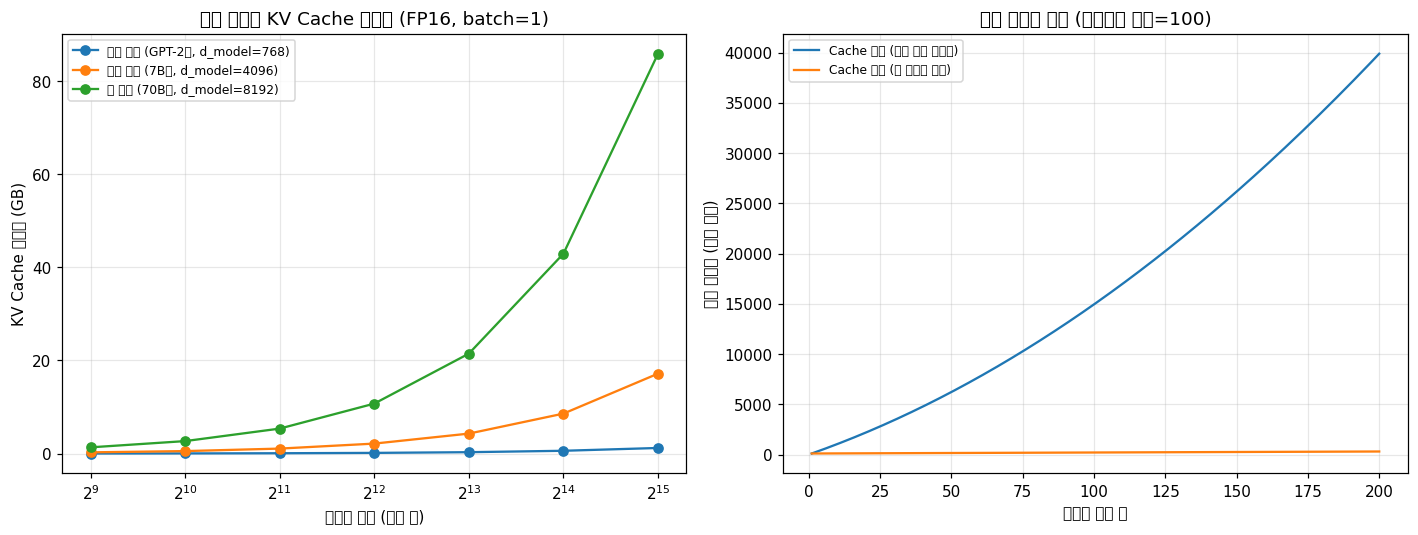

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글이 네모(□)로 깨지지 않도록, 시스템에 설치된 한글 폰트를 찾아 사용합니다.
# (실행 환경마다 설치된 폰트 이름이 달라 여러 후보를 순서대로 시도합니다. Colab이라면
#  런타임에 `!apt -qq install fonts-nanum` 실행 후 "NanumGothic"이 잡히는 경우가 많습니다.)
_korean_font_candidates = ["Noto Sans CJK KR", "NanumGothic", "Malgun Gothic", "AppleGothic"]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
for _font_name in _korean_font_candidates:
    if _font_name in _available_fonts:
        plt.rcParams["font.family"] = _font_name
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: 모델 크기별 KV Cache 메모리 vs 시퀀스 길이 ──
seq_lens = [512, 1024, 2048, 4096, 8192, 16384, 32768]
model_configs = {
    "작은 모델 (GPT-2급, d_model=768)": dict(n_layers=12, n_heads=12, d_head=64),
    "중간 모델 (7B급, d_model=4096)": dict(n_layers=32, n_heads=32, d_head=128),
    "큰 모델 (70B급, d_model=8192)": dict(n_layers=80, n_heads=64, d_head=128),
}
for label, cfg in model_configs.items():
    bytes_per_token = kv_cache_bytes_per_token(**cfg)  # dtype_bytes 기본값(2, FP16) 사용
    mem_gb = [bytes_per_token * s / 1e9 for s in seq_lens]
    axes[0].plot(seq_lens, mem_gb, marker='o', label=label)

axes[0].set_xlabel("시퀀스 길이 (토큰 수)")
axes[0].set_ylabel("KV Cache 메모리 (GB)")
axes[0].set_title("모델 크기별 KV Cache 메모리 (FP16, batch=1)")
axes[0].set_xscale('log', base=2)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── 오른쪽: 생성 토큰 수에 따른 누적 연산량 (cache 없음 vs 있음) ──
prompt_len_chart = 100
max_steps_chart = 200
steps = list(range(1, max_steps_chart + 1))
no_cache_cum, with_cache_cum = simulate_compute_cost(prompt_len_chart, max_steps_chart)

axes[1].plot(steps, no_cache_cum, label='Cache 없음 (매번 전체 재계산)')
axes[1].plot(steps, with_cache_cum, label='Cache 사용 (새 토큰만 계산)')
axes[1].set_xlabel("생성한 토큰 수")
axes[1].set_ylabel("누적 연산량 (임의 단위)")
axes[1].set_title(f"누적 연산량 비교 (프롬프트 길이={prompt_len_chart})")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 정리

- **문제**: autoregressive 생성은 매 스텝마다 이미 계산한 K, V를 다시 계산하는 낭비가 있다.
- **해결**: 계산이 끝난 K, V를 메모리에 저장(cache)해두고, 새 토큰의 K, V만 추가로 계산해서 이어붙인다.
- **효과**: 생성 스텝당 계산량이 시퀀스 길이에 비례(선형)하는 수준으로 줄어든다 (원래는 제곱에 가깝게 늘어났음).
- **대가**: 그만큼 GPU 메모리를 사용한다. 메모리 사용량은 레이어 수, head 수, head 차원, 시퀀스 길이, 배치 크기, 데이터 타입에 비례해서 커진다.
- **검증**: cache를 쓰든 안 쓰든, 수학적으로 정확히 같은 결과가 나온다 (근사가 아니다).

## 더 알아보면 좋은 주제 (이 노트북에서 다루지는 않았습니다)

- **Multi-Query / Grouped-Query Attention (MQA/GQA)**: 여러 개의 Query head가 K, V head를 공유하도록 해서 KV Cache 크기 자체를 줄이는 방법. 최근 LLM(LLaMA-2 70B, LLaMA-3, Mistral 등)이 널리 사용합니다.
- **PagedAttention (vLLM)**: 운영체제의 가상 메모리처럼, KV Cache를 고정 크기 블록 단위로 나누어 관리해서 메모리 낭비를 줄이는 서빙 기법.
- **KV Cache 양자화**: 이 노트북에서 살펴본 FP8처럼, K/V 값을 더 적은 비트로 저장해서 메모리를 아끼는 방법.

이 실습에서 만든 `KVCacheAttention`, `TinyLanguageModel` 코드는 그대로 두고, 위 개념들을 하나씩 추가해보면서 실험해보는 것도 좋은 다음 단계가 될 수 있습니다.
